In [77]:
##read data##
import pandas as pd
import os
path = os.path.join(os.curdir, "iris.xlsx")
df = pd.read_excel(path)

print(df.head(),"\n")

#extract data
feature_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"] #interested features, no unammed: 5
x = df[feature_cols]   # features
y = df["target.1"]    # classes

print("size of features is:", x.shape,"\n", "n of examples is:", y.size)

#preprocecing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.25, 
    #random_state=67, 
    stratify=y #dont create unbalaced rapp of classes
)

Std=StandardScaler()

#this is real standarization
std_x_train = Std.fit_transform(x_train)

#i use params of train standarization
std_x_test = Std.transform(x_test)

#cell1 preproc 
#2 trees
#3 nn
#confrontation

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

        target  Unnamed: 5  target.1  
0  Iris-setosa         NaN         0  
1  Iris-setosa         NaN         0  
2  Iris-setosa         NaN         0  
3  Iris-setosa         NaN         0  
4  Iris-setosa         NaN         0   

size of features is: (150, 4) 
 n of examples is: 150


## 1. Pre-elaborazione dei Dati (Preprocessing)
Prima di procedere con l'addestramento del modello, il dataset originale è stato sottoposto a specifiche fasi di pre-elaborazione per ottimizzarne l'apprendimento e garantire la validità dei risultati:
* **Suddivisione del Dataset**: I dati sono stati divisi in un *Training Set* (per l'addestramento) e un *Test Set* (per la validazione finale) utilizzando la funzione `train_test_split`.
* **Stratificazione**: Durante lo split è stato specificato il parametro `stratify=y`. Questa impostazione è risultata fondamentale per far sì che la proporzione originale delle 3 classi di output (i target) rimanga bilanciata in entrambi i sottoinsiemi, prevenendo così l'addestramento di un modello sbilanciato verso la classe maggioritaria.
* **Standardizzazione**: Le feature numeriche del dataset sono state scalate utilizzando `StandardScaler`. Un'accortezza implementativa essenziale per evitare il fenomeno del *data leakage* (che invaliderebbe i test) è stata quella di calcolare i parametri di standardizzazione (tramite `fit_transform`) **esclusivamente** sul set di addestramento, limitandosi ad applicare la medesima trasformazione (tramite `transform`) sul set di test.

In [78]:
#RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import pandas as pd

ntrees = 1 #it's too easy... 1 tree or 1000 trees dont change

# 1. Inizializzazione e Addestramento
forest = RandomForestClassifier(n_estimators=ntrees, random_state=67)
forest.fit(std_x_train, y_train)

# 2. Predizione
y_pred_forest = forest.predict(std_x_test)

# 3. Valutazione: Matrice di Confusione
confusion_matrix_forest = pd.DataFrame(
    confusion_matrix(y_test, y_pred_forest),
    index=forest.classes_,
    columns=forest.classes_
)
print(f"Confusion Matrix for Random Forest ({ntrees} alberi):\n", confusion_matrix_forest)

# 4. Valutazione: Accuratezza
good_percentage = accuracy_score(y_test, y_pred_forest) * 100
print(f"\nPercentage of good predictions for Random Forest: {good_percentage:.2f}%\n")

# 5. Valutazione: Precision, Recall e F1-score
print("Report di Classificazione (Precision, Recall, F1-score):")
print(classification_report(y_test, y_pred_forest))


Confusion Matrix for Random Forest (1 alberi):
     0   1   2
0  13   0   0
1   0  11   1
2   0   0  13

Percentage of good predictions for Random Forest: 97.37%

Report di Classificazione (Precision, Recall, F1-score):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      0.92      0.96        12
           2       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



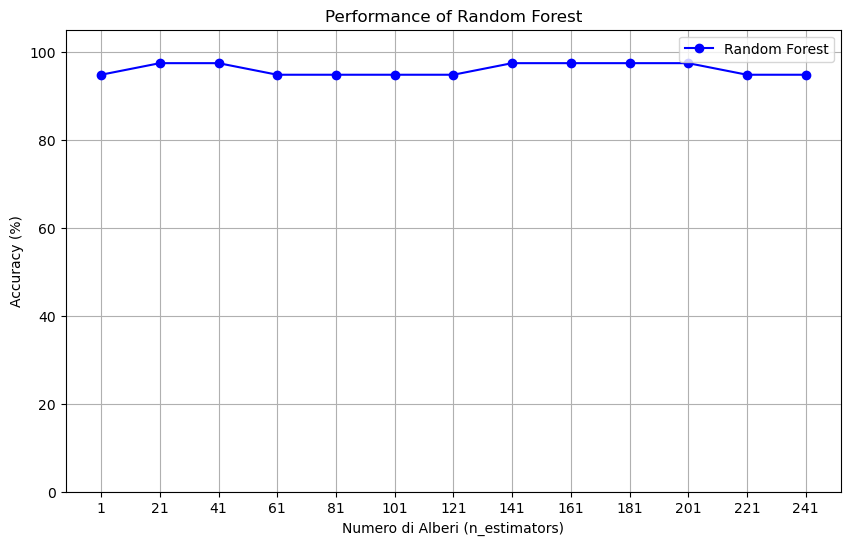

In [79]:
#performance of trees
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# function to create and rate lots of forest
def doRandomForest(ntrees, x_train, y_train, x_test, y_test):
    """
    Crea una Random Forest con 'numero_alberi', la addestra e
    restituisce sia l'accuratezza sia la confusion matrix sul test set.
    """
    forest = RandomForestClassifier(n_estimators=ntrees)
    forest.fit(x_train, y_train)
    y_pred = forest.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)
    confusion_matrix_forest = pd.DataFrame(
        confusion_matrix(y_test, y_pred),
        index=forest.classes_,
        columns=forest.classes_
    )
    return accuracy, confusion_matrix_forest


ntrees_list  = range(1, 251, 20)
risultati_accuratezza = []
risultati_confusion_matrix = []

#create and testin forest
for n in ntrees_list:
    acc, cm = doRandomForest(n, std_x_train, y_train, std_x_test, y_test)
    risultati_accuratezza.append(acc * 100) #from 0-1 to 0 and 100
    risultati_confusion_matrix.append(cm)

#plotting acc
plt.figure(figsize=(10, 6))
plt.plot(ntrees_list, risultati_accuratezza, marker='o', linestyle='-', color='b', label='Random Forest')
plt.xlabel("Numero di Alberi (n_estimators)")
plt.ylabel("Accuracy (%)")
plt.title('Performance of Random Forest')
plt.xticks(ntrees_list)
plt.grid(True)
plt.ylim(0, 105)
plt.legend()
plt.show()


## 2. Metodo di Machine Learning Classico: Analisi delle Performance del Random Forest

Il codice implementato ha l'obiettivo di addestrare un classificatore **Random Forest** e, soprattutto, di esplorare come le sue performance e la sua stabilità varino al crescere della complessità del modello (ovvero aumentando il numero di alberi decisionali).

### 2.1 Incapsulamento della Logica di Modello
Per mantenere il codice pulito e modulare, è stata definita la funzione di supporto `doRandomForest`. Questa funzione riceve in input il numero di alberi desiderato e i set di dati, occupandosi dell'intero ciclo di vita del modello per quella specifica configurazione:
* **Addestramento**: Istanzia il `RandomForestClassifier` impostando il parametro `n_estimators` e lo addestra (`fit`) sui dati di training.
* **Valutazione**: Calcola le predizioni sul test set e restituisce due metriche fondamentali:
  * L'**Accuratezza** (`accuracy_score`), per misurare le performance globali.
  * La **Matrice di Confusione** (`confusion_matrix`), convertita in un DataFrame Pandas. Questa scelta implementativa è molto utile perché indicizza righe e colonne con i nomi reali delle classi (`forest.classes_`), facilitando l'analisi degli specifici errori di classificazione (es. falsi positivi tra due classi simili).

### 2.2 Ricerca Sperimentale del Parametro Ottimale (Tuning)
Invece di addestrare un singolo modello con i parametri di default, si è scelto di testare empiricamente la robustezza dell'algoritmo. 
È stata definita una lista di valori per il numero di alberi (da 1 a 241, con step di 20, tramite `range(1, 251, 20)`). Attraverso un ciclo `for`, il modello viene ri-addestrato per ogni configurazione, salvando di volta in volta l'accuratezza (scalata in percentuale) e la matrice di confusione corrispondente. Questo approccio sistematico ci permette di tracciare la curva di apprendimento del modello.

### 2.3 Visualizzazione e Osservazioni
L'ultima parte del codice utilizza `matplotlib` per generare un grafico a linee che mette in relazione il **Numero di Alberi** (asse X) e l'**Accuratezza in percentuale** (asse Y). 

Analizzando l'andamento della curva, emerge chiaramente che il dataset affrontato risulta essere **tremendamente elementare** per questo tipo di algoritmo. L'accuratezza, infatti, non mostra un miglioramento progressivo e continuo all'aumentare della complessità del modello: di fatto, **bastava un solo albero decisionale** per raggiungere immediatamente il picco delle prestazioni.

Da questa osservazione deriva un'importante conclusione: l'errore residuo che si riscontra sul Test Set (lo scarto che impedisce di raggiungere il 100% di accuratezza) non è dovuto a una mancanza di capacità predittiva del modello. Tale errore è invece determinato dalla natura intrinseca del dataset, ovvero da **inaccuratezze dei dati** (rumore o misurazioni ambigue) o dalla presenza di **dati non linearmente separabili** (caratteristica nota per due delle tre classi di questo specifico problema), ostacoli che un semplice aumento del numero di alberi non è in grado di superare.

In [80]:
import torch.nn as nn
import torch

ReteNeurale1 = nn.Sequential( #standard
    nn.Linear(4, 16), 
    nn.ReLU(),        
    nn.Linear(16, 3)  
)

ReteNeurale2 = nn.Sequential( #no relu
    nn.Linear(4, 16), 
    nn.Linear(16, 3)  
)

ReteNeurale3 = nn.Sequential( #extreme
    nn.Linear(4, 16000), 
    nn.ReLU(),        
    nn.Linear(16000, 3)  
)

ReteNeurale4 = nn.Sequential( #tiny
    nn.Linear(4, 4), 
    nn.ReLU(),        
    nn.Linear(4, 3)  
)

rtx = torch.device("cuda" if torch.cuda.is_available() else "cpu") #use my rtx
loss_f = nn.CrossEntropyLoss() 
Netwoks = [ReteNeurale1, ReteNeurale2, ReteNeurale3, ReteNeurale4]

# epochs requested by you
epoch_list = range(1, 1002, 25) 
results = {f'Net {i+1}': [] for i in range(len(Netwoks))}

for epochs in epoch_list:
    for i, net in enumerate(Netwoks):
        optimizer = torch.optim.Adam(net.parameters(), lr=0.01)
        net.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            outputs = net(torch.tensor(std_x_train, dtype=torch.float32))
            loss = loss_f(outputs, torch.tensor(y_train.values, dtype=torch.long))
            loss.backward()
            optimizer.step()

        net.eval()
        with torch.no_grad():
            outputs = net(torch.tensor(std_x_test, dtype=torch.float32))
            _, predicted = torch.max(outputs.data, 1)
            accuracy = (predicted == torch.tensor(y_test.values, dtype=torch.long)).sum().item() / len(y_test) * 100
            results[f'Net {i+1}'].append(accuracy)
            print(f"Epochs={epochs} | Net {i+1}: {accuracy:.2f}%")


Epochs=1 | Net 1: 68.42%
Epochs=1 | Net 2: 44.74%
Epochs=1 | Net 3: 86.84%
Epochs=1 | Net 4: 2.63%
Epochs=26 | Net 1: 86.84%
Epochs=26 | Net 2: 86.84%
Epochs=26 | Net 3: 94.74%
Epochs=26 | Net 4: 63.16%
Epochs=51 | Net 1: 97.37%
Epochs=51 | Net 2: 97.37%
Epochs=51 | Net 3: 97.37%
Epochs=51 | Net 4: 89.47%
Epochs=76 | Net 1: 97.37%
Epochs=76 | Net 2: 97.37%
Epochs=76 | Net 3: 97.37%
Epochs=76 | Net 4: 97.37%
Epochs=101 | Net 1: 97.37%
Epochs=101 | Net 2: 97.37%
Epochs=101 | Net 3: 94.74%
Epochs=101 | Net 4: 97.37%
Epochs=126 | Net 1: 97.37%
Epochs=126 | Net 2: 97.37%
Epochs=126 | Net 3: 94.74%
Epochs=126 | Net 4: 97.37%
Epochs=151 | Net 1: 94.74%
Epochs=151 | Net 2: 97.37%
Epochs=151 | Net 3: 94.74%
Epochs=151 | Net 4: 97.37%
Epochs=176 | Net 1: 94.74%
Epochs=176 | Net 2: 97.37%
Epochs=176 | Net 3: 94.74%
Epochs=176 | Net 4: 97.37%
Epochs=201 | Net 1: 94.74%
Epochs=201 | Net 2: 97.37%
Epochs=201 | Net 3: 94.74%
Epochs=201 | Net 4: 97.37%
Epochs=226 | Net 1: 94.74%
Epochs=226 | Net 2: 97

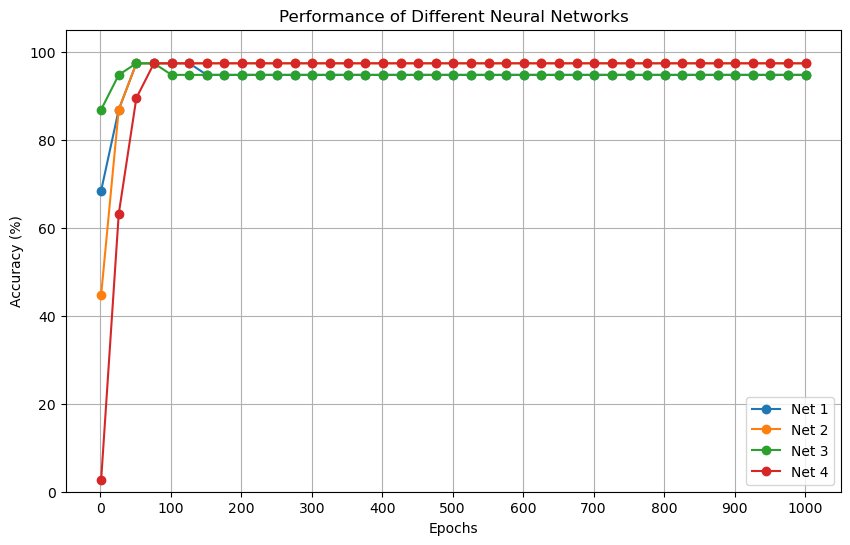

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for i in range(len(Netwoks)):
    plt.plot(epoch_list, results[f'Net {i+1}'], marker='o', label=f'Net {i+1}')

plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Performance of Different Neural Networks')
plt.xticks(range(0, 1001, 100))
plt.ylim(0, 105)
plt.grid(True)
plt.legend()
plt.show()


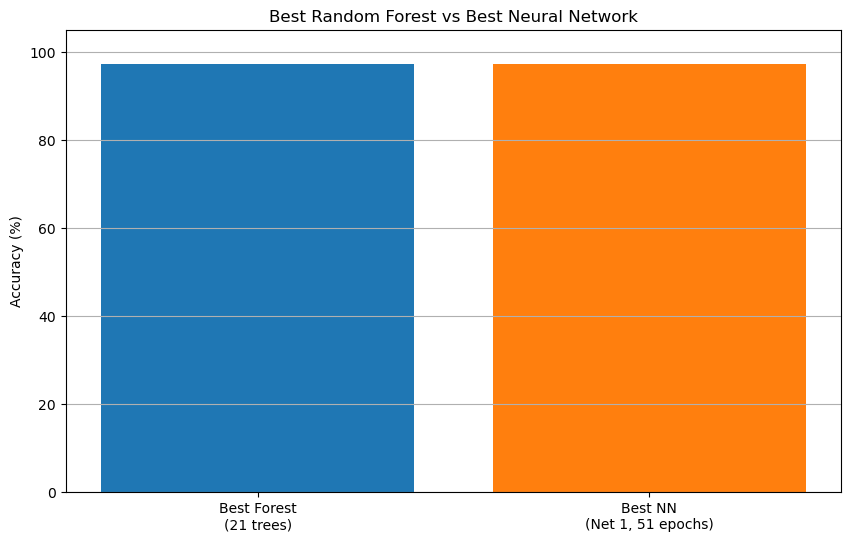

Best Forest: 97.37% with 21 trees
Best NN: 97.37% with Net 1 at 51 epochs


In [82]:
best_forest_idx = max(range(len(risultati_accuratezza)), key=lambda i: risultati_accuratezza[i])
best_forest_acc = risultati_accuratezza[best_forest_idx]
best_forest_trees = list(ntrees_list)[best_forest_idx]

best_nn_acc = -1
best_nn_name = ''
best_nn_epochs = 0
for net_name, acc_list in results.items():
    for epochs, acc in zip(epoch_list, acc_list):
        if acc > best_nn_acc:
            best_nn_acc = acc
            best_nn_name = net_name
            best_nn_epochs = epochs

plt.figure(figsize=(10, 6))
labels = [f'Best Forest\n({best_forest_trees} trees)', f'Best NN\n({best_nn_name}, {best_nn_epochs} epochs)']
values = [best_forest_acc, best_nn_acc]
plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'])
plt.ylabel('Accuracy (%)')
plt.title('Best Random Forest vs Best Neural Network')
plt.ylim(0, 105)
plt.grid(True, axis='y')
plt.show()

print(f'Best Forest: {best_forest_acc:.2f}% with {best_forest_trees} trees')
print(f'Best NN: {best_nn_acc:.2f}% with {best_nn_name} at {best_nn_epochs} epochs')
